# Notebook 04 — Análisis SHAP
**TFM:** Detección de fraude — comparativa de modelos y generalización cross-domain

**Prerrequisito:** Haber ejecutado notebook_03_modelos_ULB.ipynb

⚠️ Antes de ejecutar: actualiza MODEL_1 y MODEL_2 con los nombres de los 2 mejores modelos según la tabla del notebook 03.

**Librerías necesarias:**
pip install shap pandas numpy matplotlib seaborn joblib


In [44]:
# !pip install shap pandas numpy matplotlib seaborn joblib


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, joblib, warnings, os
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
np.random.seed(42)

print("✅ Librerías cargadas correctamente")
print(f"   shap version: {shap.__version__}")


✅ Librerías cargadas correctamente
   shap version: 0.51.0


## 1. Configuración — actualiza con tus 2 mejores modelos

In [46]:
# ⚠️  ACTUALIZA ESTOS VALORES con los resultados del notebook 03
# Ejemplo: si tus mejores modelos son XGB+SMOTE y LGBM+ADASYN:
MODEL_1_NAME     = "XGB"        # Nombre del modelo (LR, DT, RF, XGB, LGBM)
MODEL_1_STRATEGY = "None"      # Estrategia (None, SMOTE, ADASYN)

MODEL_2_NAME     = "RF"       # Segundo mejor modelo
MODEL_2_STRATEGY = "SMOTE"      # Estrategia del segundo

# Cargar particiones
X_test  = pd.read_csv("data_splits/X_test.csv")
y_test  = pd.read_csv("data_splits/y_test.csv").squeeze()
X_train = pd.read_csv("data_splits/X_train.csv")

print(f"Modelos a analizar:")
print(f"  1: {MODEL_1_NAME} + {MODEL_1_STRATEGY}")
print(f"  2: {MODEL_2_NAME} + {MODEL_2_STRATEGY}")


Modelos a analizar:
  1: XGB + None
  2: RF + SMOTE


In [47]:
# Cargar modelos entrenados
key1 = f"{MODEL_1_NAME}_{MODEL_1_STRATEGY}"
key2 = f"{MODEL_2_NAME}_{MODEL_2_STRATEGY}"

pipeline1 = joblib.load(f"resultados/model_{key1}.pkl")
pipeline2 = joblib.load(f"resultados/model_{key2}.pkl")

# Extraer clasificador del pipeline
clf1 = pipeline1.named_steps["classifier"]
clf2 = pipeline2.named_steps["classifier"]

print(f"✅ Modelos cargados")
print(f"   Modelo 1: {clf1.__class__.__name__}")
print(f"   Modelo 2: {clf2.__class__.__name__}")


✅ Modelos cargados
   Modelo 1: XGBClassifier
   Modelo 2: RandomForestClassifier


## 2. Cálculo de valores SHAP

In [48]:
explainer1 = get_explainer(clf1, X_train.sample(500, random_state=42))
sv1_raw = explainer1.shap_values(X_shap)

# Normalizar formato: algunos modelos devuelven (n, features, 2), otros (2, n, features) u otros
def extract_shap_class1(sv):
    """Extrae siempre los SHAP values de la clase 1 (fraude) en formato (n_muestras, n_features)."""
    if isinstance(sv, list):
        # Lista de arrays: [clase0, clase1]
        return np.array(sv[1])
    arr = np.array(sv)
    if arr.ndim == 3:
        # Shape (n, features, 2) → tomar última dimensión clase 1
        if arr.shape[-1] == 2:
            return arr[:, :, 1]
        # Shape (2, n, features) → tomar primer dim clase 1
        if arr.shape[0] == 2:
            return arr[1]
    return arr  # ya es 2D (n, features)

shap_values1 = extract_shap_class1(sv1_raw)
print(f"✅ SHAP Modelo 1 ({MODEL_1_NAME}): shape={shap_values1.shape}")

explainer2 = get_explainer(clf2, X_train.sample(500, random_state=42))
sv2_raw = explainer2.shap_values(X_shap)
shap_values2 = extract_shap_class1(sv2_raw)
print(f"✅ SHAP Modelo 2 ({MODEL_2_NAME}): shape={shap_values2.shape}")
print()
print("Verificación — ambos deben ser 2D (n_muestras, n_features):")
print(f"  shap_values1.ndim = {shap_values1.ndim}  ✅" if shap_values1.ndim == 2 else f"  shap_values1.ndim = {shap_values1.ndim}  ❌")
print(f"  shap_values2.ndim = {shap_values2.ndim}  ✅" if shap_values2.ndim == 2 else f"  shap_values2.ndim = {shap_values2.ndim}  ❌")


✅ SHAP Modelo 1 (XGB): shape=(2000, 30)
✅ SHAP Modelo 2 (RF): shape=(2000, 30)

Verificación — ambos deben ser 2D (n_muestras, n_features):
  shap_values1.ndim = 2  ✅
  shap_values2.ndim = 2  ✅


## 3. Importancia global — Beeswarm plots

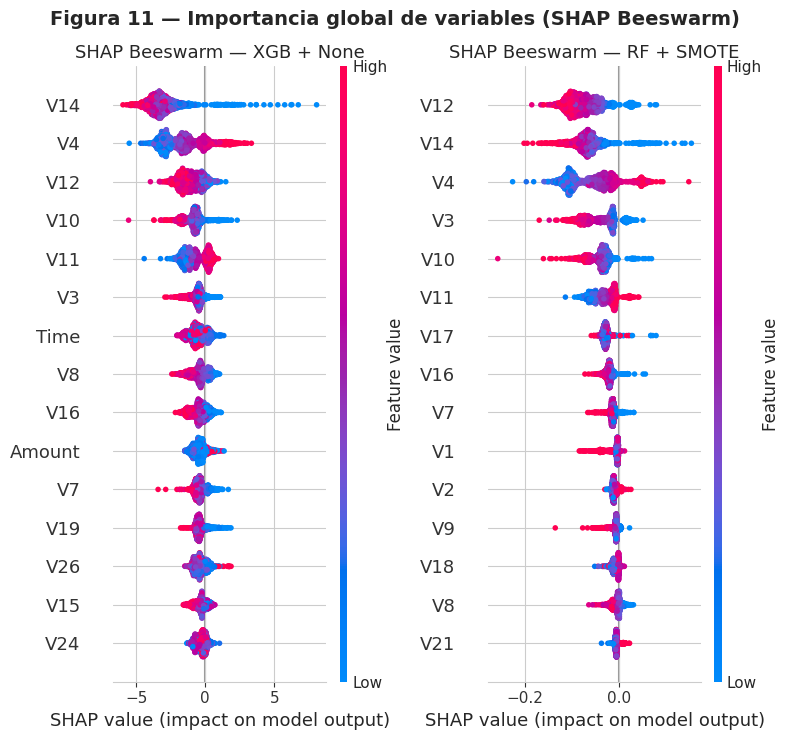

✅ fig11_shap_beeswarm.png guardada


In [49]:
os.makedirs("resultados", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values1, X_shap, show=False, max_display=15, plot_type="dot")
axes[0].set_title(f"SHAP Beeswarm — {MODEL_1_NAME} + {MODEL_1_STRATEGY}", fontsize=13)

plt.sca(axes[1])
shap.summary_plot(shap_values2, X_shap, show=False, max_display=15, plot_type="dot")
axes[1].set_title(f"SHAP Beeswarm — {MODEL_2_NAME} + {MODEL_2_STRATEGY}", fontsize=13)

plt.suptitle("Figura 11 — Importancia global de variables (SHAP Beeswarm)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/fig11_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig11_shap_beeswarm.png guardada")


### Figura 9 (versión final, usada en el TFM)

El tutor comentó que el beeswarm con 15 variables no se leía bien y sugirió reducirlo a las 9 variables PCA más discriminativas en un array de 3x3. Se reemplaza el gráfico anterior por dos grids de 3x3 (uno por modelo), donde cada panel muestra la dispersión de valores SHAP de una variable coloreada por su valor.

In [ ]:
# ── FIGURA 9 (revisada): SHAP en array 3x3 para las 9 variables más discriminativas ──
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def top9(shap_values, cols):
    imp = pd.Series(np.abs(shap_values).mean(axis=0), index=cols).sort_values(ascending=False)
    return imp.head(9).index.tolist()

def plot_shap_grid(shap_values, X, feats, title, fname):
    cols = X.columns.tolist()
    fig, axes = plt.subplots(3, 3, figsize=(13, 11))
    rng = np.random.default_rng(42)
    for ax, feat in zip(axes.flat, feats):
        j = cols.index(feat)
        fvals = X[feat].values
        svals = shap_values[:, j]
        vmin, vmax = np.percentile(fvals, 2), np.percentile(fvals, 98)
        if vmin == vmax:
            vmin, vmax = fvals.min(), fvals.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        ax.scatter(svals, rng.uniform(-0.4, 0.4, size=len(svals)),
                   c=fvals, cmap="coolwarm", norm=norm, s=14, alpha=0.75, edgecolors="none")
        ax.axvline(0, color="grey", lw=0.6, ls="--")
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.set_yticks([])
        ax.set_xlabel("Valor SHAP", fontsize=8)
        ax.tick_params(labelsize=7)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    sm = cm.ScalarMappable(cmap="coolwarm", norm=mcolors.Normalize(vmin=0, vmax=1))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Bajo", "Alto"])
    cbar.set_label("Valor de la variable", fontsize=9)
    fig.tight_layout(rect=[0, 0, 0.9, 0.95])
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    return fig

top1 = top9(shap_values1, X_shap.columns)
top2 = top9(shap_values2, X_shap.columns)

plot_shap_grid(shap_values1, X_shap, top1, f"SHAP — {MODEL_1_NAME} + {MODEL_1_STRATEGY} (top 9 variables)",
               "resultados/fig9_shap_xgb_3x3.png")
plot_shap_grid(shap_values2, X_shap, top2, f"SHAP — {MODEL_2_NAME} + {MODEL_2_STRATEGY} (top 9 variables)",
               "resultados/fig9_shap_rf_3x3.png")

# Combinar ambos grids en una sola imagen (izquierda: modelo 1, derecha: modelo 2)
from PIL import Image
im1 = Image.open("resultados/fig9_shap_xgb_3x3.png")
im2 = Image.open("resultados/fig9_shap_rf_3x3.png")
h = max(im1.height, im2.height)
combo = Image.new("RGB", (im1.width + im2.width, h), "white")
combo.paste(im1, (0, (h - im1.height) // 2))
combo.paste(im2, (im1.width, (h - im2.height) // 2))
combo.save("resultados/fig9_shap_combinado.png")
print("✅ fig9_shap_combinado.png guardada (versión final usada en el TFM)")


## 4. Importancia global — Bar plots comparativos

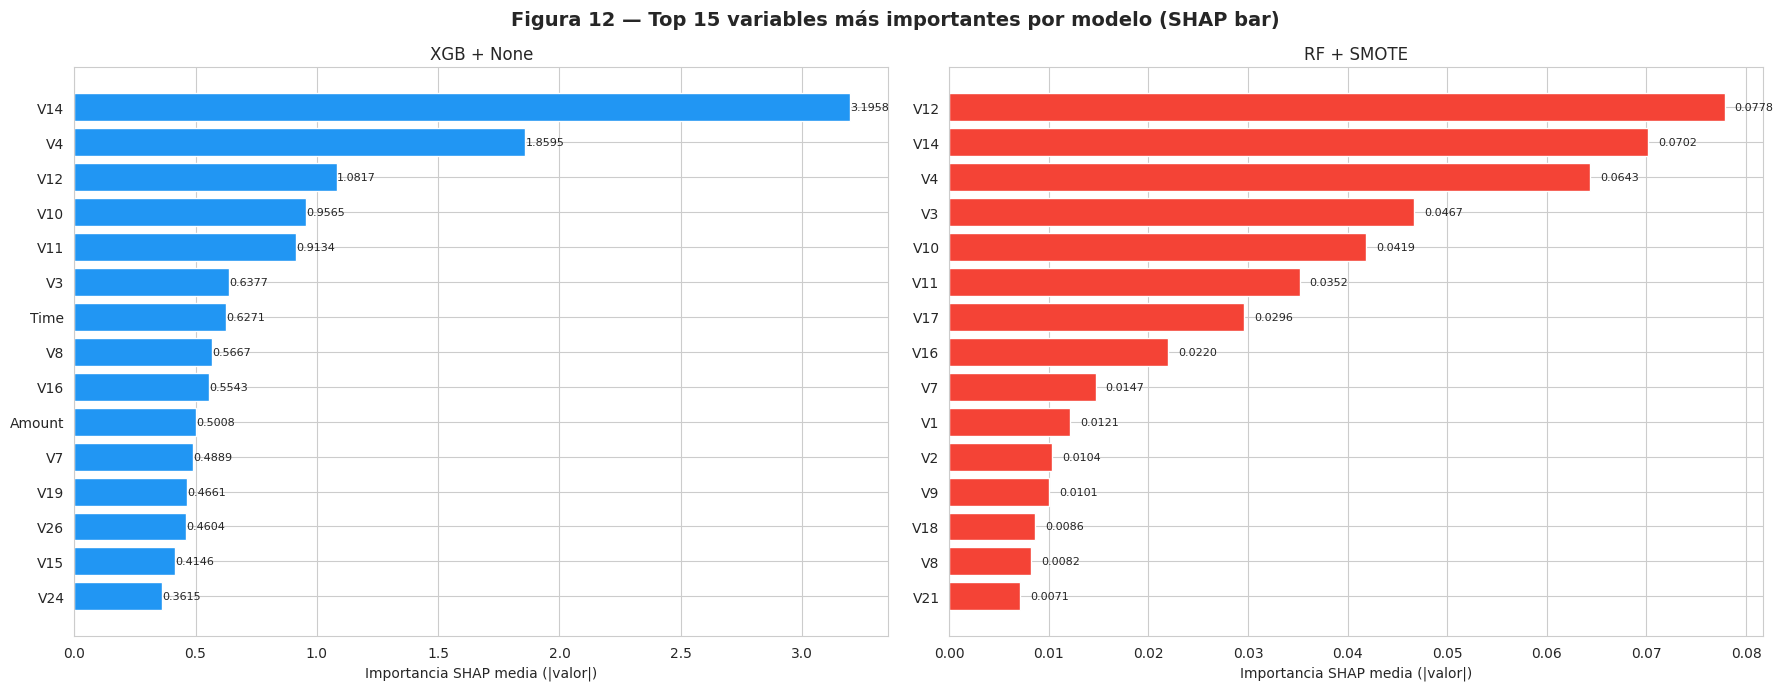

✅ fig12_shap_barplot.png guardada
=== TABLA COMPARATIVA DE IMPORTANCIA SHAP ===
 Rank XGB Variable XGB  SHAP XGB  Rank RF Variable RF  SHAP RF
        1          V14    3.1958        1         V12   0.0778
        2           V4    1.8595        2         V14   0.0702
        3          V12    1.0817        3          V4   0.0643
        4          V10    0.9565        4          V3   0.0467
        5          V11    0.9134        5         V10   0.0419
        6           V3    0.6377        6         V11   0.0352
        7         Time    0.6271        7         V17   0.0296
        8           V8    0.5667        8         V16   0.0220
        9          V16    0.5543        9          V7   0.0147
       10       Amount    0.5008       10          V1   0.0121
       11           V7    0.4889       11          V2   0.0104
       12          V19    0.4661       12          V9   0.0101
       13          V26    0.4604       13         V18   0.0086
       14          V15    0.4146      

In [50]:
# Importancia media absoluta por variable (ambos ya son 2D)
importance1 = pd.Series(
    np.abs(shap_values1).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

importance2 = pd.Series(
    np.abs(shap_values2).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Modelo 1
top_vars1 = importance1.head(top_n)
axes[0].barh(top_vars1.index[::-1], top_vars1.values[::-1], color="#2196F3", edgecolor="white")
axes[0].set_xlabel("Importancia SHAP media (|valor|)")
axes[0].set_title(f"{MODEL_1_NAME} + {MODEL_1_STRATEGY}")
for i, v in enumerate(top_vars1.values[::-1]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

# Modelo 2
top_vars2 = importance2.head(top_n)
axes[1].barh(top_vars2.index[::-1], top_vars2.values[::-1], color="#F44336", edgecolor="white")
axes[1].set_xlabel("Importancia SHAP media (|valor|)")
axes[1].set_title(f"{MODEL_2_NAME} + {MODEL_2_STRATEGY}")
for i, v in enumerate(top_vars2.values[::-1]):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

plt.suptitle("Figura 12 — Top 15 variables más importantes por modelo (SHAP bar)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/fig12_shap_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig12_shap_barplot.png guardada")

# Tabla comparativa
comp_table = pd.DataFrame({
    f"Rank {MODEL_1_NAME}"     : list(range(1, top_n+1)),
    f"Variable {MODEL_1_NAME}" : importance1.head(top_n).index.tolist(),
    f"SHAP {MODEL_1_NAME}"     : importance1.head(top_n).round(4).values,
    f"Rank {MODEL_2_NAME}"     : list(range(1, top_n+1)),
    f"Variable {MODEL_2_NAME}" : importance2.head(top_n).index.tolist(),
    f"SHAP {MODEL_2_NAME}"     : importance2.head(top_n).round(4).values,
})
print("=== TABLA COMPARATIVA DE IMPORTANCIA SHAP ===")
print(comp_table.to_string(index=False))
comp_table.to_csv("resultados/tabla_shap_importancia.csv", index=False)
print("✅ tabla_shap_importancia.csv guardada")


## 5. Explicaciones locales — transacciones individuales

Fraudes detectados (TP)       : 2
Fraudes no detectados (FN)    : 2
Legítimas bloqueadas (FP)     : 1


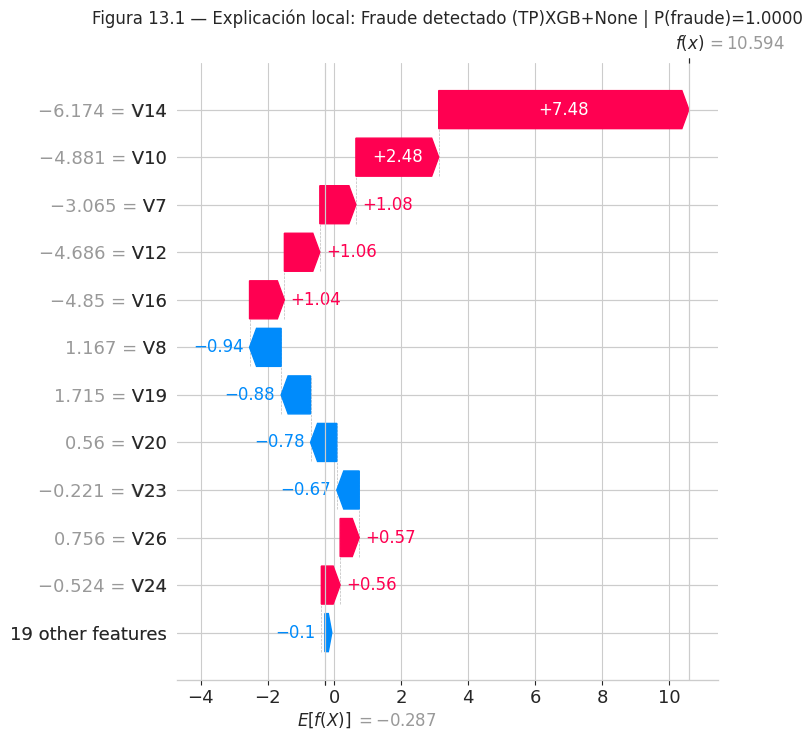

✅ resultados/fig13_1_shap_waterfall_TP.png guardada


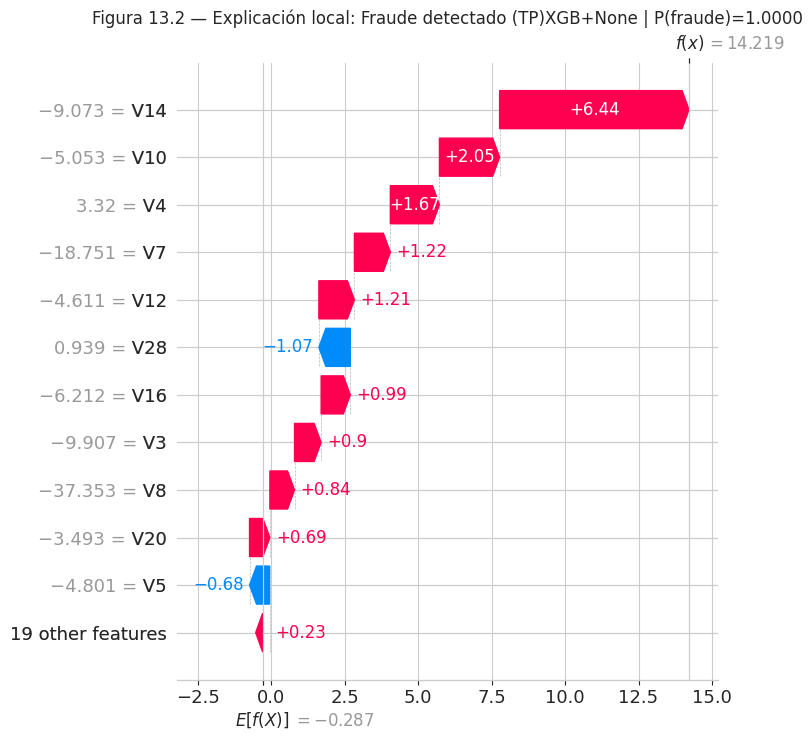

✅ resultados/fig13_2_shap_waterfall_TP.png guardada


In [51]:
# Seleccionar transacciones para explicación local
y_pred_test  = pipeline1.predict(X_test)
y_proba_test = pipeline1.predict_proba(X_test)[:, 1]

tp_idx = X_test.index[(y_test.values == 1) & (y_pred_test == 1)].tolist()[:2]
fn_idx = X_test.index[(y_test.values == 1) & (y_pred_test == 0)].tolist()[:2]
fp_idx = X_test.index[(y_test.values == 0) & (y_pred_test == 1)].tolist()[:1]

print(f"Fraudes detectados (TP)       : {len(tp_idx)}")
print(f"Fraudes no detectados (FN)    : {len(fn_idx)}")
print(f"Legítimas bloqueadas (FP)     : {len(fp_idx)}")

# Obtener expected_value base
base_val = explainer1.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(np.array(base_val).flat[1])  # clase 1
else:
    base_val = float(base_val)

for idx_num, idx in enumerate(tp_idx):
    sample   = X_test.loc[[idx]]
    sv_local = explainer1.shap_values(sample)
    sv_local = extract_shap_class1(sv_local)  # → (1, 30)
    sv_row   = sv_local[0]                    # → (30,)

    explanation = shap.Explanation(
        values        = sv_row,
        base_values   = base_val,
        data          = sample.values[0],
        feature_names = sample.columns.tolist()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    shap.waterfall_plot(explanation, show=False, max_display=12)
    proba_val = float(y_proba_test[X_test.index.get_loc(idx)])
    plt.title(f"Figura 13.{idx_num+1} — Explicación local: Fraude detectado (TP)"
        f"{MODEL_1_NAME}+{MODEL_1_STRATEGY} | P(fraude)={proba_val:.4f}"
    )
    plt.tight_layout()
    fname = f"resultados/fig13_{idx_num+1}_shap_waterfall_TP.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ {fname} guardada")


## 6. Resumen de hallazgos SHAP

In [52]:
print("=" * 60)
print("RESUMEN — Análisis SHAP")
print("=" * 60)
print()
print(f"Top 5 variables más importantes — {MODEL_1_NAME}:")
for i, (var, val) in enumerate(importance1.head(5).items(), 1):
    print(f"  {i}. {var}: {val:.4f}")
print()
print(f"Top 5 variables más importantes — {MODEL_2_NAME}:")
for i, (var, val) in enumerate(importance2.head(5).items(), 1):
    print(f"  {i}. {var}: {val:.4f}")
print()

# Variables en común top 5
common = set(importance1.head(5).index) & set(importance2.head(5).index)
print(f"Variables en común en el top 5: {common}")
print()
print("Archivos generados:")
for f in ["fig11_shap_beeswarm.png", "fig12_shap_barplot.png",
          "fig13_1_shap_waterfall_TP.png", "fig13_2_shap_waterfall_TP.png",
          "tabla_shap_importancia.csv"]:
    print(f"  ✅ resultados/{f}")
print()
print("➡️  Siguiente paso: ejecutar notebook_05_generalizacion_IEEE_CIS.ipynb")


RESUMEN — Análisis SHAP

Top 5 variables más importantes — XGB:
  1. V14: 3.1958
  2. V4: 1.8595
  3. V12: 1.0817
  4. V10: 0.9565
  5. V11: 0.9134

Top 5 variables más importantes — RF:
  1. V12: 0.0778
  2. V14: 0.0702
  3. V4: 0.0643
  4. V3: 0.0467
  5. V10: 0.0419

Variables en común en el top 5: {'V14', 'V12', 'V10', 'V4'}

Archivos generados:
  ✅ resultados/fig11_shap_beeswarm.png
  ✅ resultados/fig12_shap_barplot.png
  ✅ resultados/fig13_1_shap_waterfall_TP.png
  ✅ resultados/fig13_2_shap_waterfall_TP.png
  ✅ resultados/tabla_shap_importancia.csv

➡️  Siguiente paso: ejecutar notebook_05_generalizacion_IEEE_CIS.ipynb
